# 000 — Arquivos LAS em Python com `lasio`

**Objetivo:** reconhecer a estrutura de um LAS, ler cabeçalhos e curvas,
converter o conteúdo em `DataFrame`, fazer controle de qualidade básico e
gravar uma nova versão sem perder metadados.

O exemplo utilizado é realizado a partir do poço `15/9-13` do conjunto FORCE 2020. Em um projeto real, use o LAS original e confirme sempre
unidades, referência de profundidade, valor nulo e proveniência.

### Roteiro completo

| Notebook | Tema |
|---|---|
| 000 | LAS, metadados e curvas |
| 001 | Preparação, ausências, extremos e visualização |
| 002 | Cinco técnicas de regressão e validação |
| 003 | Correção de intervalo e rastreabilidade |

## Preparação online no Google Colab

O notebook monta o Google Drive e usa a pasta:

`Meu Drive/Curso_Regressao_Pocos/`

Na primeira execução, o dataset é baixado para `dados/`. Depois disso ele é
reutilizado nos demais notebooks. O LAS de exemplo também fica nessa pasta.

In [1]:
from pathlib import Path
import subprocess
import sys

try:
    from google.colab import drive
    EM_COLAB = True
except ImportError:
    EM_COLAB = False

if EM_COLAB:
    drive.mount("/content/drive")
    PASTA_CURSO = Path("/content/drive/MyDrive/Curso_Regressao_Pocos")
else:
    PASTA_CURSO = Path.cwd()

PASTA_DADOS = PASTA_CURSO / "dados"
PASTA_SAIDAS = PASTA_CURSO / "saidas"
PASTA_DADOS.mkdir(parents=True, exist_ok=True)
PASTA_SAIDAS.mkdir(parents=True, exist_ok=True)

ID_DADOS_DRIVE = "1u6_1ZMPIDy-agKZnKVUCp0t0bvK8ccPC"
candidatos_dados = [
    PASTA_DADOS / "dataset.csv",
]
ARQUIVO_DADOS = next((p for p in candidatos_dados if p.exists()), None)

if ARQUIVO_DADOS is None:
    try:
        import gdown
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown

    ARQUIVO_DADOS = PASTA_DADOS / "dataset.csv"
    gdown.download(id=ID_DADOS_DRIVE, output=str(ARQUIVO_DADOS), quiet=False)

if not ARQUIVO_DADOS.exists():
    raise FileNotFoundError("O dataset não foi localizado nem baixado.")

print(f"Ambiente: {'Google Colab' if EM_COLAB else 'local'}")
print(f"Pasta do curso: {PASTA_CURSO}")
print(f"Dataset: {ARQUIVO_DADOS}")


try:
    import lasio
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lasio"])
    import lasio

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)

Mounted at /content/drive
Ambiente: Google Colab
Pasta do curso: /content/drive/MyDrive/Curso_Regressao_Pocos
Dataset: /content/drive/MyDrive/Curso_Regressao_Pocos/dados/dataset.csv


## 1. Localizar e abrir o arquivo

Um LAS é texto estruturado em seções iniciadas por `~`:

- `~V`: versão;
- `~W`: informações do poço;
- `~C`: descrição das curvas e unidades;
- `~P`: parâmetros;
- `~O`: observações livres;
- `~A`: tabela de dados.

Diferentemente do LAS, o DLIS é binário e pode guardar múltiplos frames e
objetos. Para DLIS, uma biblioteca comum é `dlisio`; aqui o foco é `lasio`.


In [2]:
POCO_EXEMPLO = "15/9-13"
CAMINHO_LAS = PASTA_DADOS / "poco_15-9-13_exemplo.las"

if not CAMINHO_LAS.exists():
    colunas = [
        "WELL", "DEPTH_MD", "CALI", "RMED", "RDEP", "RHOB",
        "GR", "NPHI", "DTC", "FORCE_2020_LITHOFACIES_LITHOLOGY", "GROUP",
    ]
    fonte = pd.read_csv(ARQUIVO_DADOS, usecols=colunas)
    exemplo = (
        fonte.loc[fonte["WELL"].eq(POCO_EXEMPLO)]
        .sort_values("DEPTH_MD")
        .reset_index(drop=True)
    )
    if exemplo.empty:
        raise ValueError(f"Poço {POCO_EXEMPLO} não encontrado no dataset.")

    grupos = {
        nome: codigo
        for codigo, nome in enumerate(sorted(fonte["GROUP"].dropna().unique()))
    }
    exemplo["GROUP_CODE"] = exemplo["GROUP"].map(grupos)
    exemplo["LITH_CODE"] = exemplo[
        "FORCE_2020_LITHOFACIES_LITHOLOGY"
    ]

    novo_las = lasio.LASFile()
    novo_las.well.WELL.value = POCO_EXEMPLO
    novo_las.well.STRT.value = float(exemplo["DEPTH_MD"].min())
    novo_las.well.STOP.value = float(exemplo["DEPTH_MD"].max())
    novo_las.well.STEP.value = float(exemplo["DEPTH_MD"].diff().median())
    novo_las.well.NULL.value = -999.25
    novo_las.other = (
        "LAS de exemplo derivado do FORCE 2020.\n"
        "GROUP_CODE: "
        + "; ".join(f"{codigo}={nome}" for nome, codigo in grupos.items())
    )

    curvas = {
        "DEPTH_MD": ("M", "Measured depth"),
        "CALI": ("IN", "Caliper"),
        "RMED": ("OHM.M", "Medium resistivity"),
        "RDEP": ("OHM.M", "Deep resistivity"),
        "RHOB": ("G/CC", "Bulk density"),
        "GR": ("GAPI", "Gamma ray"),
        "NPHI": ("V/V", "Neutron porosity"),
        "DTC": ("US/F", "Compressional slowness"),
        "LITH_CODE": ("CODE", "FORCE 2020 lithology code"),
        "GROUP_CODE": ("CODE", "Stratigraphic group code"),
    }
    for curva, (unidade, descricao) in curvas.items():
        novo_las.append_curve(
            curva,
            exemplo[curva].to_numpy(),
            unit=unidade,
            descr=descricao,
        )
    novo_las.write(str(CAMINHO_LAS), version=2.0)
    print(f"LAS de exemplo criado: {CAMINHO_LAS}")

poco = lasio.read(CAMINHO_LAS)
print(f"Arquivo: {CAMINHO_LAS}")
print(f"Seções: {list(poco.sections)}")

Arquivo: /content/drive/MyDrive/Curso_Regressao_Pocos/dados/poco_15-9-13_exemplo.las
Seções: ['Version', 'Well', 'Curves', 'Parameter', 'Other']


### Antes da biblioteca: enxergue o arquivo como texto

`lasio` facilita o trabalho, mas o aluno precisa reconhecer o que a
biblioteca está interpretando. Observe abaixo a transição entre cabeçalho,
catálogo de curvas e dados. Essa inspeção rápida costuma revelar versão,
unidades ou mnemônicos inesperados antes de qualquer processamento.


In [3]:
with CAMINHO_LAS.open("r", encoding="utf-8", errors="replace") as arquivo:
    primeiras_linhas = [next(arquivo) for _ in range(45)]

print("".join(primeiras_linhas))

~Version ---------------------------------------------------
VERS.   2.0 : CWLS log ASCII Standard -VERSION 2.0
WRAP.    NO : One line per depth step
DLM . SPACE : Column Data Section Delimiter
~Well ------------------------------------------------------
STRT.M  494.52800 : START DEPTH
STOP.M 3272.02400 : STOP DEPTH
STEP.M    0.15200 : STEP
NULL.     -999.25 : NULL VALUE
COMP.             : COMPANY
WELL.     15/9-13 : WELL
FLD .             : FIELD
LOC .             : LOCATION
PROV.             : PROVINCE
CNTY.             : COUNTY
STAT.             : STATE
CTRY.             : COUNTRY
SRVC.             : SERVICE COMPANY
DATE.             : DATE
UWI .             : UNIQUE WELL ID
API .             : API NUMBER
~Curve Information -----------------------------------------
DEPTH_MD  .M      : Measured depth
CALI      .IN     : Caliper
RMED      .OHM.M  : Medium resistivity
RDEP      .OHM.M  : Deep resistivity
RHOB      .G/CC   : Bulk density
GR        .GAPI   : Gamma ray
NPHI      .V/V    

> **Erro comum:** assumir que todo LAS usa `DEPT`, metros e os mesmos
> mnemônicos. Em dados reais podem aparecer `MD`, `DEPTH`, `TDEP`, pés, curvas
> repetidas (`GR:1`, `GR:2`) e valores nulos diferentes de `-999.25`.
> Primeiro leia o cabeçalho; depois padronize.


## 2. Inspecionar metadados antes das curvas


In [4]:
metadados_poco = pd.DataFrame(
    [
        {
            "mnemônico": item.mnemonic,
            "valor": item.value,
            "unidade": item.unit,
            "descrição": item.descr,
        }
        for item in poco.well
    ]
)
metadados_poco


,mnemônico,valor,unidade,descrição
0,STRT,494.528,M,START DEPTH
1,STOP,3272.024,M,STOP DEPTH
2,STEP,0.152,M,STEP
3,NULL,-999.25,,NULL VALUE
4,COMP,,,COMPANY
5,WELL,15/9-13,,WELL
6,FLD,,,FIELD
7,LOC,,,LOCATION
8,PROV,,,PROVINCE
9,CNTY,,,COUNTY


In [5]:
catalogo_curvas = pd.DataFrame(
    [
        {
            "mnemônico": curva.mnemonic,
            "unidade": curva.unit or "—",
            "descrição": curva.descr,
        }
        for curva in poco.curves
    ]
)
catalogo_curvas


,mnemônico,unidade,descrição
0,DEPTH_MD,M,Measured depth
1,CALI,IN,Caliper
2,RMED,OHM.M,Medium resistivity
3,RDEP,OHM.M,Deep resistivity
4,RHOB,G/CC,Bulk density
5,GR,GAPI,Gamma ray
6,NPHI,V/V,Neutron porosity
7,DTC,US/F,Compressional slowness
8,LITH_CODE,CODE,FORCE 2020 lithology code
9,GROUP_CODE,CODE,Stratigraphic group code


## 3. Converter para `DataFrame` e auditar


In [6]:
logs = poco.df().reset_index()
coluna_profundidade = logs.columns[0]
if coluna_profundidade != "DEPTH_MD":
    logs = logs.rename(columns={coluna_profundidade: "DEPTH_MD"})
logs = logs.sort_values("DEPTH_MD").reset_index(drop=True)

resumo = pd.DataFrame(
    {
        "tipo": logs.dtypes.astype(str),
        "nulos_%": (100 * logs.isna().mean()).round(2),
        "mínimo": logs.min(numeric_only=True),
        "máximo": logs.max(numeric_only=True),
    }
)
display(logs.head())
display(resumo)

,DEPTH_MD,CALI,RMED,RDEP,RHOB,GR,NPHI,DTC,LITH_CODE,GROUP_CODE
0,494.528,19.48083,1.61141,1.79868,1.88419,80.20085,NaN,161.13118,65000.0,6.0
1,494.680,19.46880,1.61807,1.79564,1.88979,79.26289,NaN,160.60347,65000.0,6.0
2,494.832,19.46880,1.62646,1.80073,1.89652,74.82200,NaN,160.17361,65000.0,6.0
3,494.984,19.45928,1.62159,1.80152,1.89191,72.87892,NaN,160.14943,65000.0,6.0
4,495.136,19.45310,1.60268,1.79530,1.88003,71.72914,NaN,160.12834,65000.0,6.0


,tipo,nulos_%,mínimo,máximo
DEPTH_MD,float64,0.00,494.52800,3272.02400
CALI,float64,0.00,8.18661,23.32957
RMED,float64,0.00,0.37499,142.60634
RDEP,float64,0.00,0.35220,49.22190
RHOB,float64,0.00,1.40458,2.92789
GR,float64,0.00,6.19151,499.02258
NPHI,float64,23.20,0.02433,0.80026
DTC,float64,0.44,55.72675,175.95314
LITH_CODE,float64,0.00,30000.00000,99000.00000
GROUP_CODE,float64,0.00,2.00000,12.00000


In [7]:
passo = logs["DEPTH_MD"].diff()
print(f"Intervalo de profundidade: {logs.DEPTH_MD.min():.2f}–{logs.DEPTH_MD.max():.2f} m")
print(f"Passo mediano: {passo.median():.4f} m")
print(f"Passos não positivos: {(passo.dropna() <= 0).sum()}")
print(f"Profundidades duplicadas: {logs.DEPTH_MD.duplicated().sum()}")


Intervalo de profundidade: 494.53–3272.02 m
Passo mediano: 0.1520 m
Passos não positivos: 0
Profundidades duplicadas: 0


## 4. Controle de qualidade simples

Limites abaixo são **exemplos didáticos**, não regras universais. Antes de
remover valores, confronte unidade, ferramenta, ambiente de poço e geologia.
Guardamos uma curva nova (`GR_QC`) para preservar o dado bruto.


In [8]:
logs["GR_QC"] = logs["GR"].where(logs["GR"].between(0, 300))
logs["RDEP_POSITIVA"] = logs["RDEP"].where(logs["RDEP"] > 0)

qc = pd.Series(
    {
        "GR fora de 0–300 gAPI": (~logs["GR"].between(0, 300)).sum(),
        "RDEP não positiva": (logs["RDEP"] <= 0).sum(),
        "DTC ausente": logs["DTC"].isna().sum(),
    },
    name="n_amostras",
)
qc.to_frame()


,n_amostras
GR fora de 0–300 gAPI,5
RDEP não positiva,0
DTC ausente,81


## 5. Visualizar por profundidade


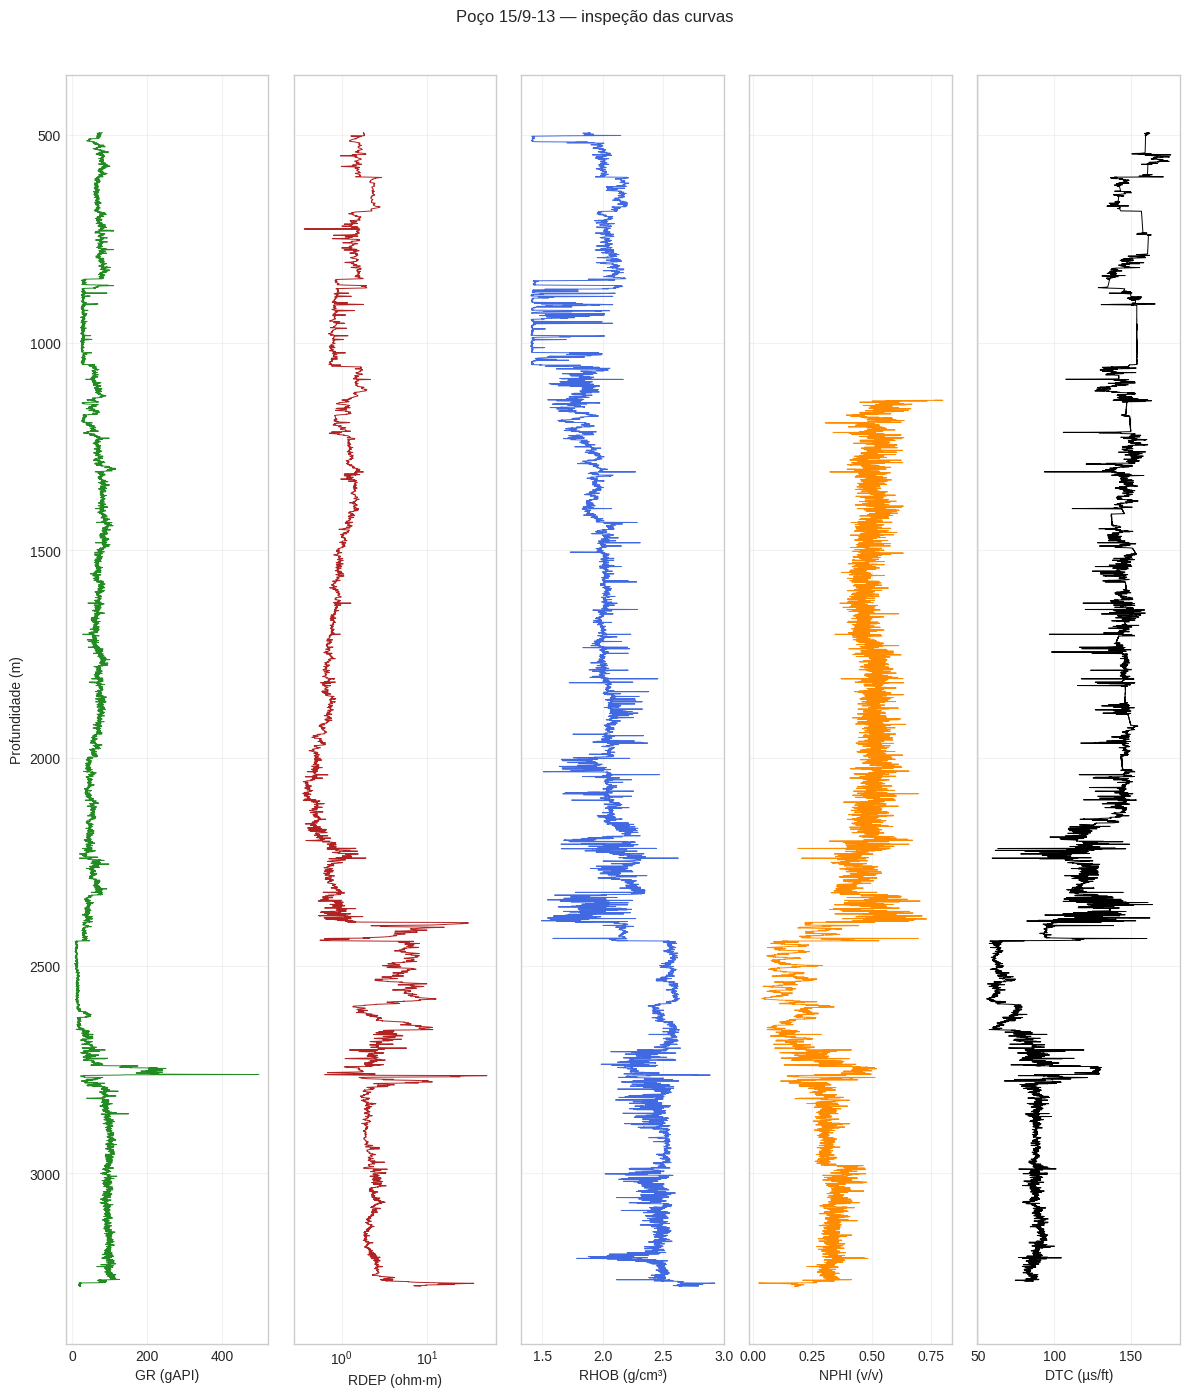

In [9]:

fig, axes = plt.subplots(1, 5, figsize=(12, 14), sharey=True)

axes[0].plot(logs["GR"], logs["DEPTH_MD"], color="forestgreen", lw=0.7)
axes[0].set(xlabel="GR (gAPI)", ylabel="Profundidade (m)")

axes[1].semilogx(logs["RDEP"], logs["DEPTH_MD"], color="firebrick", lw=0.7)
axes[1].set_xlabel("RDEP (ohm·m)")

axes[2].plot(logs["RHOB"], logs["DEPTH_MD"], color="royalblue", lw=0.7)
axes[2].set_xlabel("RHOB (g/cm³)")

axes[3].plot(logs["NPHI"], logs["DEPTH_MD"], color="darkorange", lw=0.7)
axes[3].set_xlabel("NPHI (v/v)")

axes[4].plot(logs["DTC"], logs["DEPTH_MD"], color="black", lw=0.7)
axes[4].set_xlabel("DTC (µs/ft)")

for ax in axes:
    ax.grid(alpha=0.25)
axes[0].invert_yaxis()
fig.suptitle("Poço 15/9-13 — inspeção das curvas", y=0.995)
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()


## 6. Contexto geológico no LAS

`LITH_CODE` representa a litologia/fácies rotulada no desafio FORCE 2020.
`GROUP_CODE` representa o **grupo estratigráfico**, codificado apenas porque o
LAS armazena curvas numéricas. **Formação não está disponível no dataset**.

Esses atributos podem vir de tabelas de tops, mudlogs ou interpretações
externas e precisam ser alinhados pela mesma referência de profundidade.


In [10]:
logs[["DEPTH_MD", "LITH_CODE", "GROUP_CODE"]].head()


,DEPTH_MD,LITH_CODE,GROUP_CODE
0,494.528,65000.0,6.0
1,494.680,65000.0,6.0
2,494.832,65000.0,6.0
3,494.984,65000.0,6.0
4,495.136,65000.0,6.0


## 7. Salvar arquivo LAS

In [11]:
if "GR_QC" in [curva.mnemonic for curva in poco.curves]:
    poco["GR_QC"] = logs["GR_QC"].to_numpy()
else:
    poco.append_curve(
        "GR_QC",
        logs["GR_QC"].to_numpy(),
        unit="GAPI",
        descr="Gamma ray after didactic QC",
    )

caminho_saida = PASTA_SAIDAS / "poco_15-9-13_processado.las"
poco.write(str(caminho_saida), version=2.0)

poco_reaberto = lasio.read(caminho_saida)
assert len(poco_reaberto.index) == len(poco.index)
assert "GR_QC" in [curva.mnemonic for curva in poco_reaberto.curves]
print(f"Arquivo validado: {caminho_saida}")

Arquivo validado: /content/drive/MyDrive/Curso_Regressao_Pocos/saidas/poco_15-9-13_processado.las


## 8. O que aconteceria se ignorássemos o valor nulo?

O LAS usa um número sentinela para representar ausência. Se o arquivo fosse
lido como uma tabela comum e `-999.25` permanecesse como medida física, médias,
correlações e limites dos gráficos seriam destruídos. `lasio` converte o
sentinela em `NaN`.


In [12]:
nulos_por_curva = logs.isna().sum().sort_values(ascending=False)
extremos_suspeitos = (logs.select_dtypes("number") < -900).sum()

display(
    pd.DataFrame(
        {
            "NaN após lasio": nulos_por_curva,
            "valores < -900 restantes": extremos_suspeitos,
        }
    ).fillna(0).astype(int)
)

assert extremos_suspeitos.sum() == 0


,NaN após lasio,valores < -900 restantes
CALI,0,0
DEPTH_MD,0,0
DTC,81,0
GR,0,0
GROUP_CODE,0,0
GR_QC,5,0
LITH_CODE,0,0
NPHI,4238,0
RDEP,0,0
RDEP_POSITIVA,0,0


### Checklist antes de seguir

- [ ] Sei localizar `STRT`, `STOP`, `STEP` e `NULL`.
- [ ] Verifiquei mnemônicos e unidades.
- [ ] Converti para `DataFrame` sem perder a profundidade.
- [ ] Adicionar informações de grupo, formação e litologia.
- [ ] Mantive a curva bruta e criei uma versão de QC.
